In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import os
 
RAW_PATH  = "data/raw/"
OUT_PATH  = "data/processed/"
PLOT_PATH = "outputs/plots/"
 
 
# %% [2] Leitura dos arquivos
orders    = pd.read_csv(RAW_PATH + "olist_orders_dataset.csv")
items     = pd.read_csv(RAW_PATH + "olist_order_items_dataset.csv")
payments  = pd.read_csv(RAW_PATH + "olist_order_payments_dataset.csv")
reviews   = pd.read_csv(RAW_PATH + "olist_order_reviews_dataset.csv")
customers = pd.read_csv(RAW_PATH + "olist_customers_dataset.csv")
products  = pd.read_csv(RAW_PATH + "olist_products_dataset.csv")
sellers   = pd.read_csv(RAW_PATH + "olist_sellers_dataset.csv")
cat_map   = pd.read_csv(RAW_PATH + "product_category_name_translation.csv")
 
print("Arquivos carregados com sucesso!")

Arquivos carregados com sucesso!


In [2]:
# converte colunas de data
orders["order_purchase_timestamp"]      = pd.to_datetime(orders["order_purchase_timestamp"])
orders["order_delivered_customer_date"] = pd.to_datetime(orders["order_delivered_customer_date"])
orders["order_estimated_delivery_date"] = pd.to_datetime(orders["order_estimated_delivery_date"])
 
# mantém só pedidos entregues
orders = orders[orders["order_status"] == "delivered"].copy()
 
# calcula dias até a entrega e se foi no prazo
orders["delivery_days"] = (
    orders["order_delivered_customer_date"] - orders["order_purchase_timestamp"]
).dt.days
 
orders["on_time"] = (
    orders["order_delivered_customer_date"] <= orders["order_estimated_delivery_date"]
).astype(int)
 
# colunas de calendário para filtros no Power BI
orders["order_year"]      = orders["order_purchase_timestamp"].dt.year
orders["order_month"]     = orders["order_purchase_timestamp"].dt.month
orders["order_yearmonth"] = orders["order_purchase_timestamp"].dt.strftime("%Y-%m")
 
print(f"Pedidos entregues: {len(orders):,}")

Pedidos entregues: 96,478


In [3]:
# traduz categoria para inglês
products = products.merge(cat_map, on="product_category_name", how="left")
 
# preenche categorias sem tradução
products["product_category_name_english"] = products["product_category_name_english"].fillna("outros")

In [4]:
reviews = reviews.drop_duplicates(subset="order_id", keep="last")
reviews = reviews[["order_id", "review_score"]]

In [5]:
payments_agg = payments.groupby("order_id", as_index=False).agg(
    payment_value=("payment_value", "sum"),
    payment_type=("payment_type", "first"),
    installments=("payment_installments", "max")
)

In [6]:
items = items.drop_duplicates()
items["item_revenue"] = items["price"] + items["freight_value"]
 
# agrega por pedido
items_agg = items.groupby("order_id", as_index=False).agg(
    n_items=("order_item_id", "count"),
    total_price=("price", "sum"),
    total_freight=("freight_value", "sum"),
    total_revenue=("item_revenue", "sum")
)
 
# categoria principal por pedido
items_with_cat = items.merge(
    products[["product_id", "product_category_name_english"]],
    on="product_id", how="left"
)
items_cat = items_with_cat.groupby("order_id", as_index=False)["product_category_name_english"].first()
items_cat = items_cat.rename(columns={"product_category_name_english": "main_category"})

In [7]:
master = orders.merge(customers[["customer_id", "customer_state", "customer_city"]],
                      on="customer_id", how="left")
 
master = master.merge(items_agg,     on="order_id", how="left")
master = master.merge(items_cat,     on="order_id", how="left")
master = master.merge(payments_agg,  on="order_id", how="left")
master = master.merge(reviews,       on="order_id", how="left")
 
master = master.rename(columns={
    "customer_state": "state",
    "customer_city":  "city",
    "review_score":   "rating",
    "payment_type":   "pay_type",
    "payment_value":  "pay_value",
})
 
print(f"Shape        : {master.shape}")
print(f"Faturamento  : R$ {master['pay_value'].sum():,.2f}")
print(f"Ticket médio : R$ {master['pay_value'].mean():,.2f}")
print(f"Avaliação    : {master['rating'].mean():.2f} ★")

Shape        : (96478, 24)
Faturamento  : R$ 15,422,461.77
Ticket médio : R$ 159.86
Avaliação    : 4.16 ★


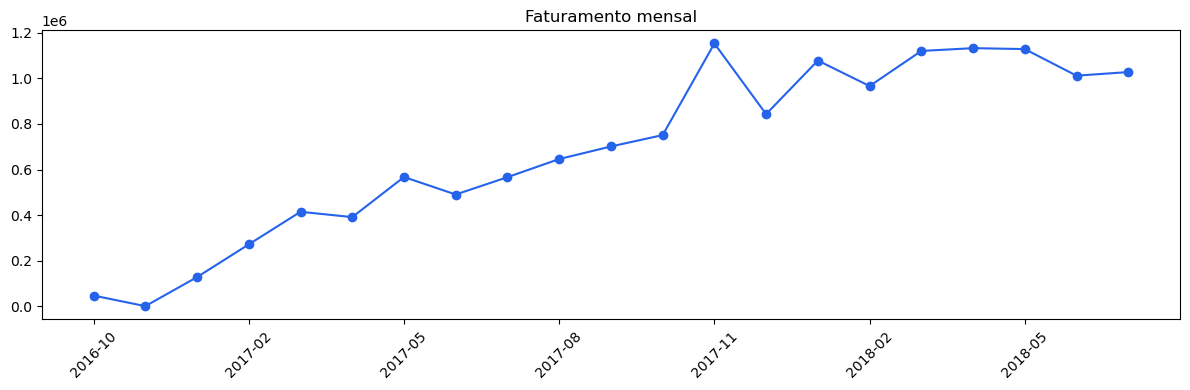

In [8]:
# faturamento mensal
rev_monthly = master.groupby("order_yearmonth")["pay_value"].sum().reset_index()
rev_monthly = rev_monthly.sort_values("order_yearmonth").iloc[1:-1]
 
plt.figure(figsize=(12, 4))
plt.plot(rev_monthly["order_yearmonth"], rev_monthly["pay_value"],
         marker="o", color="#2563EB")
plt.xticks(rev_monthly["order_yearmonth"][::3], rotation=45)
plt.title("Faturamento mensal")
plt.tight_layout()
plt.savefig(PLOT_PATH + "01_faturamento_mensal.png", dpi=150)
plt.show()

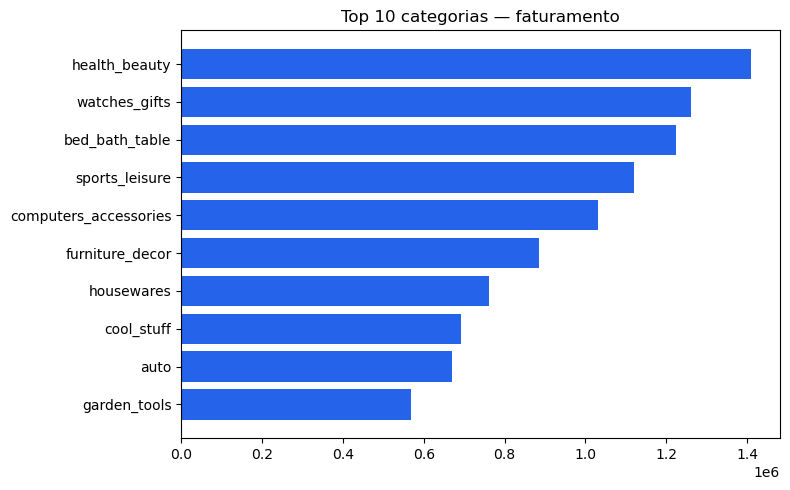

In [9]:
# top 10 categorias
top_cat = master.groupby("main_category")["pay_value"].sum().nlargest(10).sort_values()
 
plt.figure(figsize=(8, 5))
plt.barh(top_cat.index, top_cat.values, color="#2563EB")
plt.title("Top 10 categorias — faturamento")
plt.tight_layout()
plt.savefig(PLOT_PATH + "02_top_categorias.png", dpi=150)
plt.show()

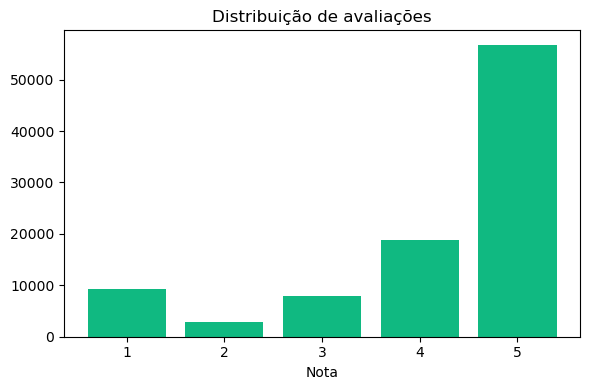

In [10]:
rating_counts = master["rating"].value_counts().sort_index()
 
plt.figure(figsize=(6, 4))
plt.bar(rating_counts.index.astype(int), rating_counts.values, color="#10B981")
plt.xticks([1, 2, 3, 4, 5])
plt.xlabel("Nota")
plt.title("Distribuição de avaliações")
plt.tight_layout()
plt.savefig(PLOT_PATH + "03_avaliacoes.png", dpi=150)
plt.show()

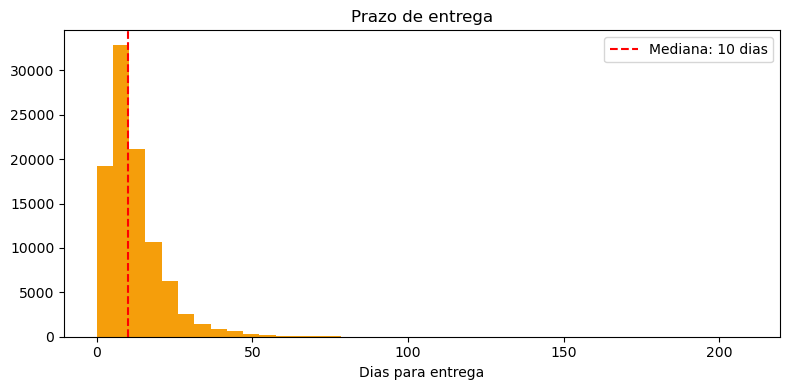

In [11]:
plt.figure(figsize=(8, 4))
plt.hist(master["delivery_days"].dropna(), bins=40, color="#F59E0B")
plt.axvline(master["delivery_days"].median(), color="red", linestyle="--",
            label=f"Mediana: {master['delivery_days'].median():.0f} dias")
plt.xlabel("Dias para entrega")
plt.title("Prazo de entrega")
plt.legend()
plt.tight_layout()
plt.savefig(PLOT_PATH + "04_prazo_entrega.png", dpi=150)
plt.show()

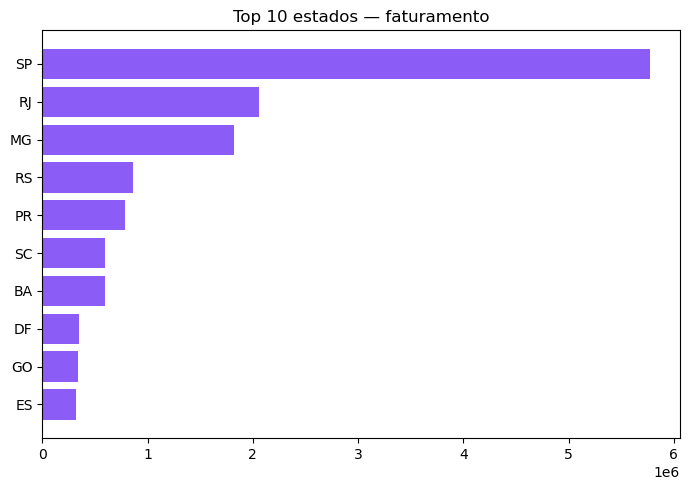

In [12]:
top_states = master.groupby("state")["pay_value"].sum().nlargest(10).sort_values()
 
plt.figure(figsize=(7, 5))
plt.barh(top_states.index, top_states.values, color="#8B5CF6")
plt.title("Top 10 estados — faturamento")
plt.tight_layout()
plt.savefig(PLOT_PATH + "05_estados.png", dpi=150)
plt.show()

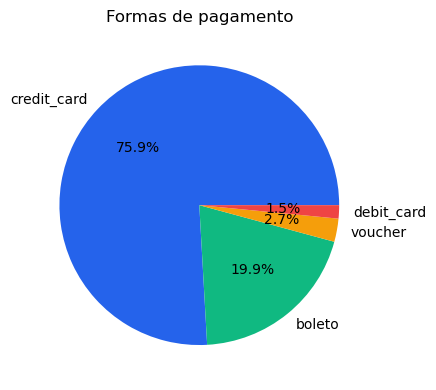

In [13]:
pay_counts = master["pay_type"].value_counts()
 
plt.figure(figsize=(6, 4))
plt.pie(pay_counts.values, labels=pay_counts.index, autopct="%1.1f%%",
        colors=["#2563EB","#10B981","#F59E0B","#EF4444"])
plt.title("Formas de pagamento")
plt.tight_layout()
plt.savefig(PLOT_PATH + "06_pagamentos.png", dpi=150)
plt.show()

In [15]:
master.to_csv(OUT_PATH + "olist_master.csv", index=False, encoding="utf-8")
print(f"olist_master.csv salvo — {master.shape[0]:,} linhas")
 
# resumo de KPIs
kpis = {
    "total_pedidos":        [len(master)],
    "faturamento_total":    [round(master["pay_value"].sum(), 2)],
    "ticket_medio":         [round(master["pay_value"].mean(), 2)],
    "avaliacao_media":      [round(master["rating"].mean(), 2)],
    "entrega_no_prazo_pct": [round(master["on_time"].mean() * 100, 1)],
    "prazo_medio_dias":     [round(master["delivery_days"].mean(), 1)],
}
pd.DataFrame(kpis).to_csv(OUT_PATH + "olist_kpis.csv", index=False)
print("olist_kpis.csv salvo")
 
# série mensal
monthly = master.groupby("order_yearmonth").agg(
    pedidos=("order_id", "count"),
    faturamento=("pay_value", "sum"),
    ticket_medio=("pay_value", "mean"),
    avaliacao_media=("rating", "mean"),
    entrega_no_prazo_pct=("on_time", "mean")
).reset_index().iloc[1:-1]
 
monthly["faturamento"]          = monthly["faturamento"].round(2)
monthly["ticket_medio"]         = monthly["ticket_medio"].round(2)
monthly["avaliacao_media"]      = monthly["avaliacao_media"].round(2)
monthly["entrega_no_prazo_pct"] = (monthly["entrega_no_prazo_pct"] * 100).round(1)
 
monthly.to_csv(OUT_PATH + "olist_monthly.csv", index=False)
print("olist_monthly.csv salvo")

olist_master.csv salvo — 96,478 linhas
olist_kpis.csv salvo
olist_monthly.csv salvo


In [16]:
print(master.columns.tolist())

['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date', 'delivery_days', 'on_time', 'order_year', 'order_month', 'order_yearmonth', 'state', 'city', 'n_items', 'total_price', 'total_freight', 'total_revenue', 'main_category', 'pay_value', 'pay_type', 'installments', 'rating']
